In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
master = pd.read_csv("../data/cleaned/master_dataset.csv")

In [4]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "shipping_limit_date"
]

for col in date_columns:
    if col in master.columns:
        master[col] = pd.to_datetime(
            master[col],
            format="mixed",
            errors="coerce"
        )

In [5]:
master.shape

(165649, 42)

In [6]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165649 entries, 0 to 165648
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       165649 non-null  object        
 1   customer_id                    165649 non-null  object        
 2   order_status                   165649 non-null  object        
 3   order_purchase_timestamp       165649 non-null  datetime64[ns]
 4   order_approved_at              165470 non-null  datetime64[ns]
 5   order_delivered_carrier_date   162883 non-null  datetime64[ns]
 6   order_delivered_customer_date  161330 non-null  datetime64[ns]
 7   order_estimated_delivery_date  165649 non-null  datetime64[ns]
 8   customer_unique_id             165649 non-null  object        
 9   customer_zip_code_prefix       165649 non-null  int64         
 10  customer_city                  165649 non-null  object        
 11  

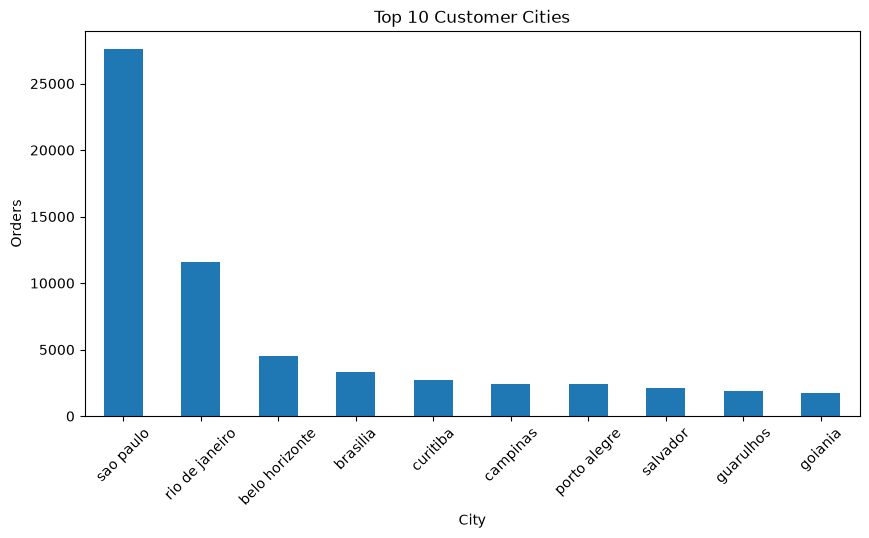

In [7]:
top_cities = master["customer_city"].value_counts().head(10)

top_cities.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customer Cities")
plt.xlabel("City")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

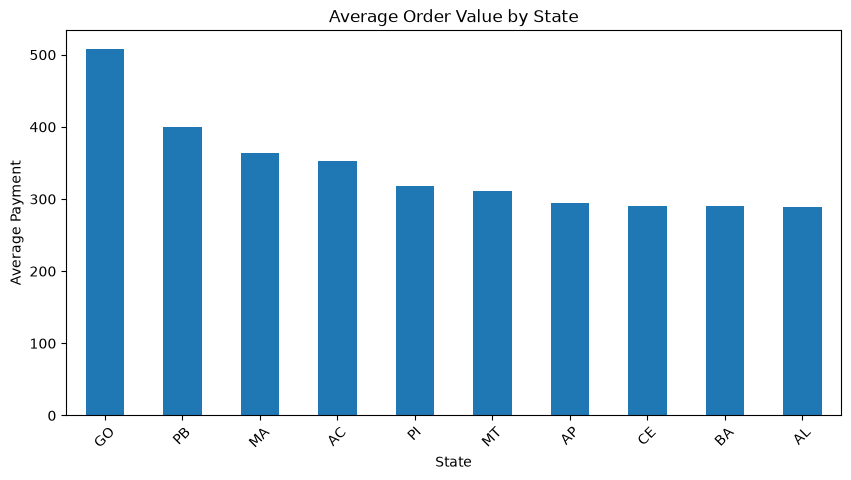

In [8]:
avg_order = master.groupby("customer_state")["payment_value"].mean().sort_values(ascending=False).head(10)

avg_order.plot(kind="bar", figsize=(10,5))

plt.title("Average Order Value by State")
plt.xlabel("State")
plt.ylabel("Average Payment")
plt.xticks(rotation=45)
plt.show()

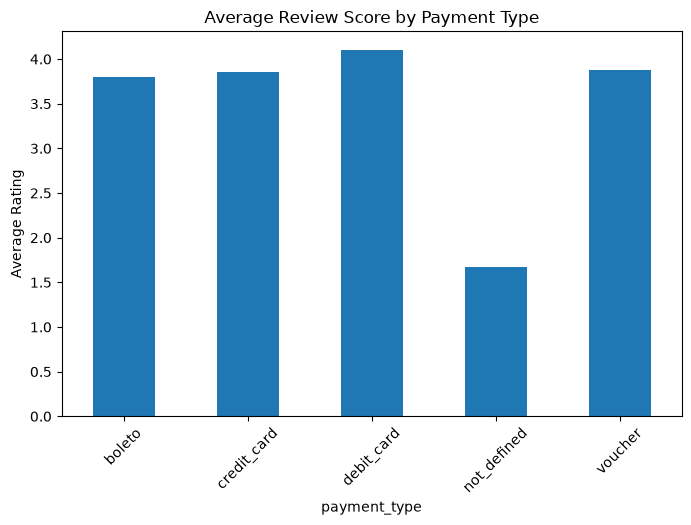

In [9]:
review_payment = master.groupby("payment_type")["review_score"].mean()

review_payment.plot(kind="bar", figsize=(8,5))

plt.title("Average Review Score by Payment Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [12]:
master["delivery_days"] = (
    master["order_delivered_customer_date"] -
    master["order_purchase_timestamp"]
).dt.days

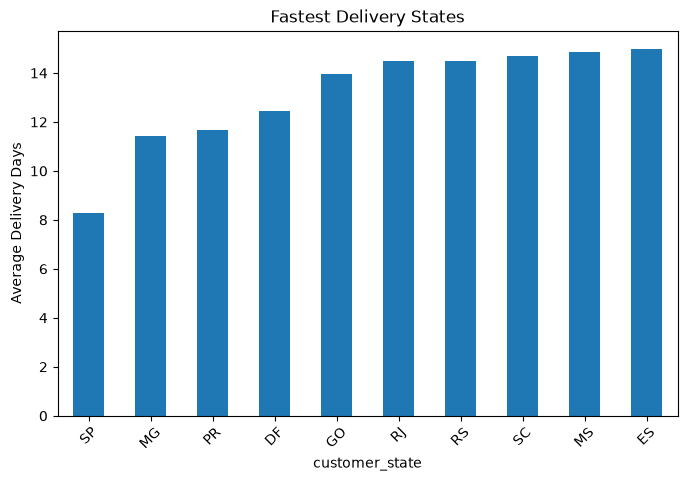

In [13]:
delivery_state = (
    master.groupby("customer_state")["delivery_days"]
    .mean()
    .sort_values()
)

delivery_state.head(10).plot(kind="bar", figsize=(8,5))

plt.title("Fastest Delivery States")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=45)
plt.show()

In [14]:
master["purchase_year"] = master["order_purchase_timestamp"].dt.year
master["purchase_month"] = master["order_purchase_timestamp"].dt.month_name()
master["purchase_day"] = master["order_purchase_timestamp"].dt.day_name()
master["purchase_hour"] = master["order_purchase_timestamp"].dt.hour

master["delivery_days"] = (
    master["order_delivered_customer_date"] -
    master["order_purchase_timestamp"]
).dt.days

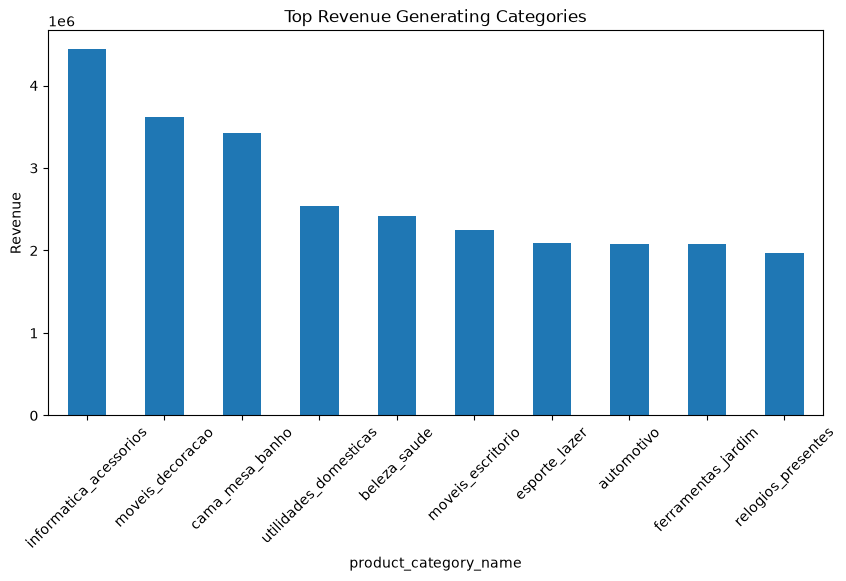

In [15]:
revenue_category = (
    master.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_category.plot(kind="bar", figsize=(10,5))

plt.title("Top Revenue Generating Categories")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

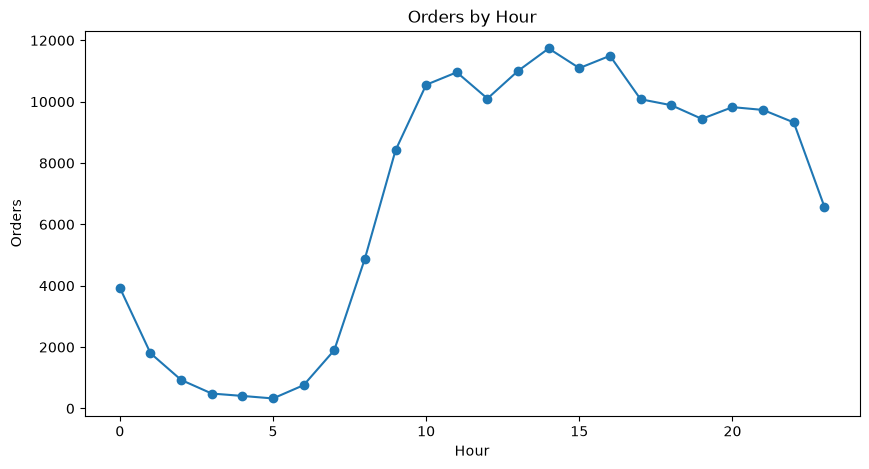

In [16]:
orders_hour = master["purchase_hour"].value_counts().sort_index()

orders_hour.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()

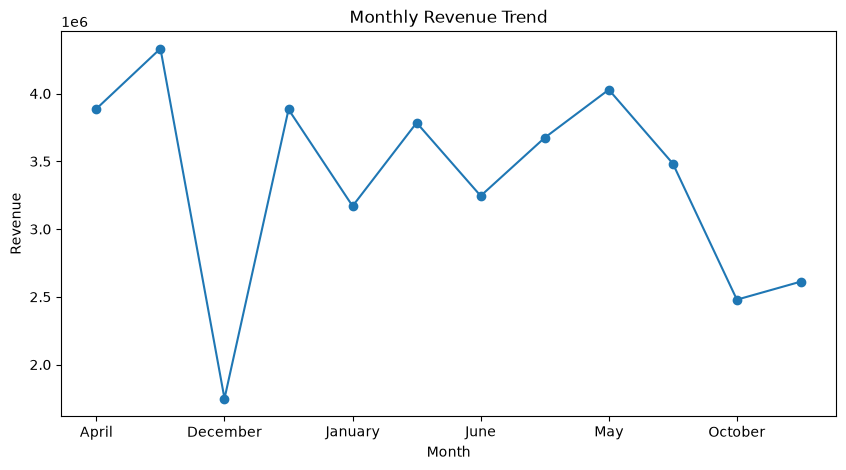

In [17]:
monthly_revenue = master.groupby("purchase_month")["payment_value"].sum()

monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [19]:
master["customer_unique_id"].nunique()

96096

In [20]:
customer_orders = master.groupby("customer_unique_id")["order_id"].nunique()

repeat = (customer_orders > 1).sum()
one_time = (customer_orders == 1).sum()

print("Repeat Customers:", repeat)
print("One-Time Customers:", one_time)

Repeat Customers: 2997
One-Time Customers: 93099


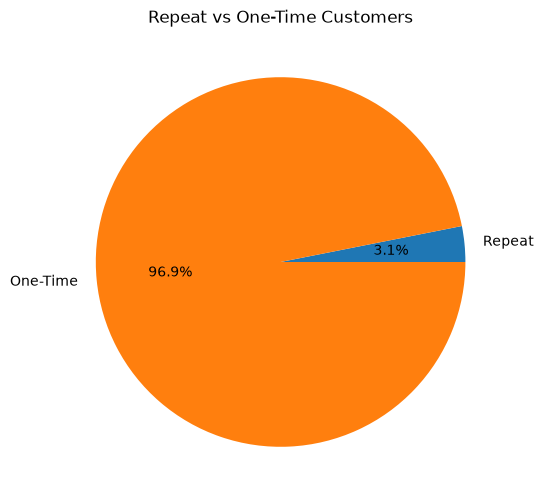

In [21]:
plt.figure(figsize=(6,6))

plt.pie(
    [repeat, one_time],
    labels=["Repeat", "One-Time"],
    autopct="%1.1f%%"
)

plt.title("Repeat vs One-Time Customers")
plt.show()

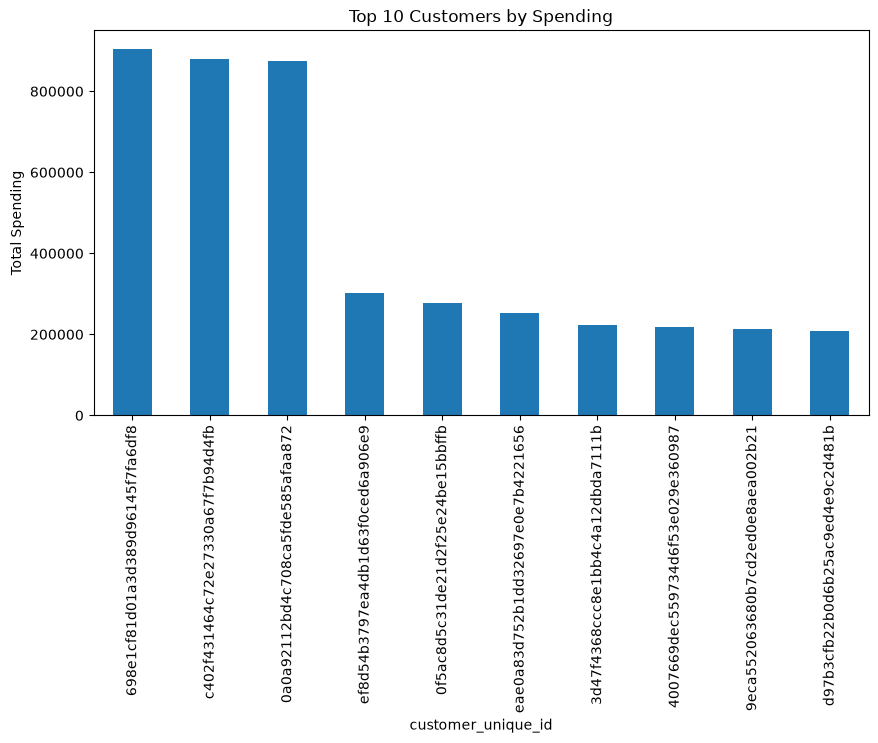

In [22]:
top_customers = (
    master.groupby("customer_unique_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Spending")
plt.ylabel("Total Spending")
plt.show()

In [23]:
clv = (
    master.groupby("customer_unique_id")["payment_value"]
    .sum()
)

clv.describe()

count     96096.000000
mean        419.675145
std        5952.171212
min           0.000000
25%          64.000000
50%         114.270000
75%         214.840000
max      905120.000000
Name: payment_value, dtype: float64

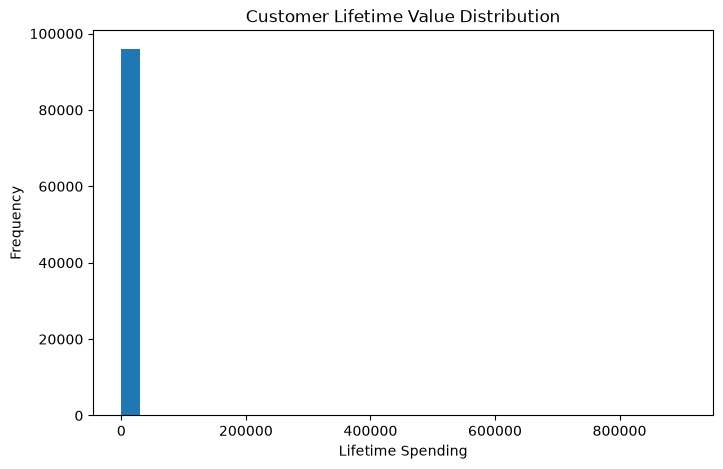

In [24]:
clv.plot(kind="hist", bins=30, figsize=(8,5))

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Lifetime Spending")
plt.show()

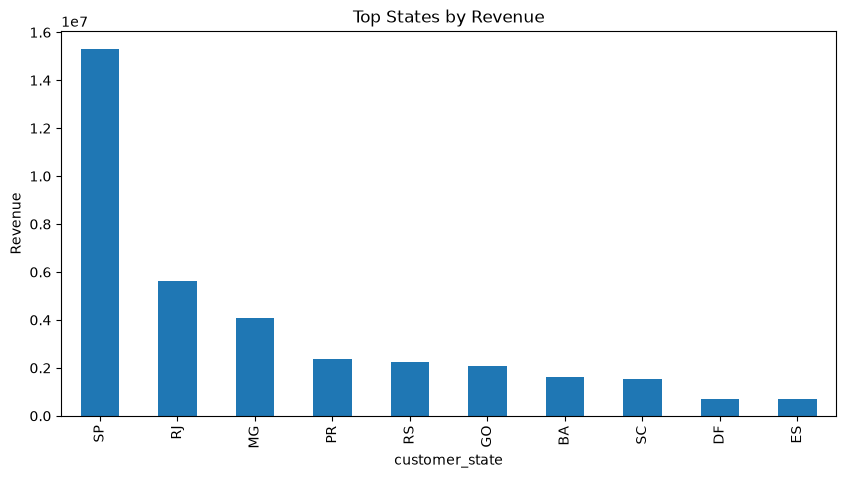

In [26]:
state_revenue = (
    master.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Top States by Revenue")
plt.ylabel("Revenue")
plt.show()

In [27]:
avg_spending = (
    master.groupby("customer_unique_id")["payment_value"]
    .mean()
)

avg_spending.describe()

count    96095.000000
mean       158.935911
std        219.774313
min          0.000000
25%         60.850000
50%        103.860000
75%        175.300000
max      13664.080000
Name: payment_value, dtype: float64

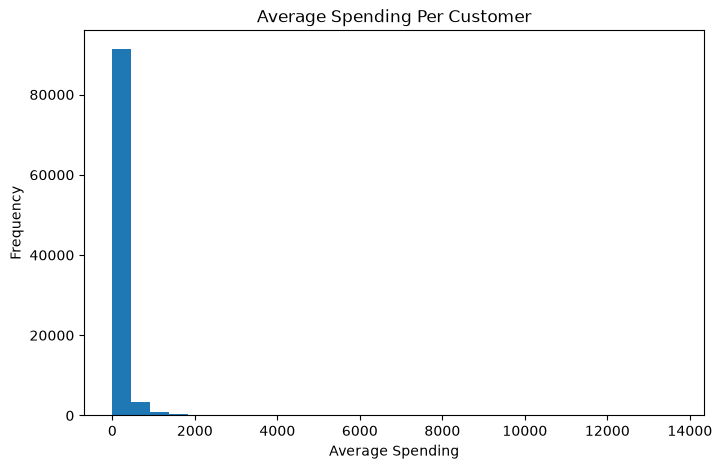

In [28]:
avg_spending.plot(kind="hist", bins=30, figsize=(8,5))

plt.title("Average Spending Per Customer")
plt.xlabel("Average Spending")
plt.show()

In [29]:
snapshot_date = master["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = master.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [30]:
rfm.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,419.675145
std,153.414676,0.214384,5952.171212
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,64.000000
50%,269.000000,1.000000,114.270000
75%,398.000000,1.000000,214.840000
max,773.000000,17.000000,905120.000000


🎯 Notebook 08 Complete

Is notebook me tumhare paas hoga:

✅ Total Customers
✅ Repeat vs One-Time Customers
✅ Top Customers
✅ Customer Lifetime Value
✅ State-wise Revenue
✅ Average Spending
✅ RFM Analysis